**Author:** [Riccardo Guidotti](http://kdd.isti.cnr.it/people/riccardo-guidotti)  
**Python version:**  3.x

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict

# Data Preparation

In [2]:
from sklearn.datasets import load_breast_cancer

frame = load_breast_cancer(as_frame=True)
df = frame['data']
X = df.values
y = np.array(frame['target'])

In [3]:
X.shape

(569, 30)

In [4]:
np.unique(y, return_counts=True)

(array([0, 1]), array([212, 357], dtype=int64))

In [5]:
Counter(y)

Counter({1: 357, 0: 212})

In [6]:
ctr = Counter(y)
ctr

Counter({1: 357, 0: 212})

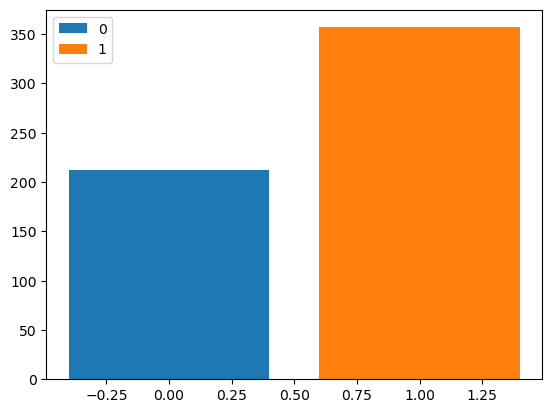

In [7]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange'])
plt.legend()
plt.show()

In [8]:
# selects 3 random elements
np.random.choice(np.arange(len(X)), 3, replace=False)

array([563,   4, 484])

In [9]:
# random index (no repetition) of all records minus 20 belonging to class 1 (majority class)
rows2remove = np.random.choice(df[y == 1].index, 357 - 20, replace=False)

In [10]:
len(df), len(rows2remove)

(569, 337)

In [11]:
df2 = df.drop(index=rows2remove, axis=0)
print(len(df2))

232


In [12]:
X2 = df2.values
y2 = np.array([y[i] for i in range(len(y)) if i not in rows2remove])

In [13]:
len(X2), len(y2)

(232, 232)

In [14]:
np.unique(y2, return_counts=True)

(array([0, 1]), array([212,  20], dtype=int64))

In [15]:
ctr2 = Counter(y2)
ctr2

Counter({0: 212, 1: 20})

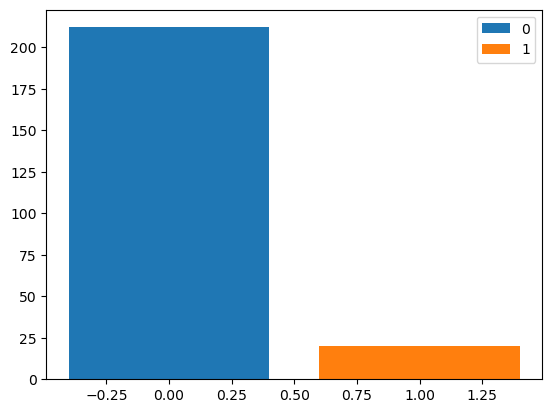

In [16]:
plt.bar(ctr2.keys(), ctr2.values(), label=ctr2.keys(), color=['tab:blue', 'tab:orange'])
plt.legend()
plt.show()

In [17]:
20/212

0.09433962264150944

## Data Partitioning

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state=100, stratify=y2)

In [20]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1]), array([148,  14], dtype=int64)),
 (array([0, 1]), array([64,  6], dtype=int64)))

In [21]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.9135802469135802

## Classification

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc

In [23]:
from sklearn.dummy import DummyClassifier

In [24]:
clf = DummyClassifier()
clf.fit(X_train, y_train)

y_pred0 = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

Accuracy 0.9142857142857143
F1-score [0.95522388 0.        ]
              precision    recall  f1-score   support

           0       0.91      1.00      0.96        64
           1       0.00      0.00      0.00         6

    accuracy                           0.91        70
   macro avg       0.46      0.50      0.48        70
weighted avg       0.84      0.91      0.87        70



c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


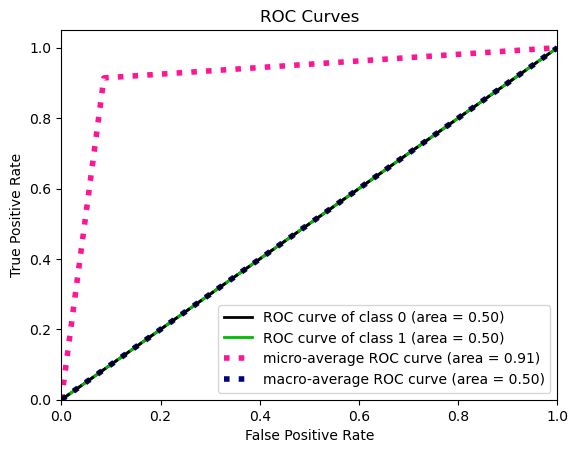

In [25]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred0 = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

Accuracy 0.9428571428571428
F1-score [0.96969697 0.5       ]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        64
           1       1.00      0.33      0.50         6

    accuracy                           0.94        70
   macro avg       0.97      0.67      0.73        70
weighted avg       0.95      0.94      0.93        70



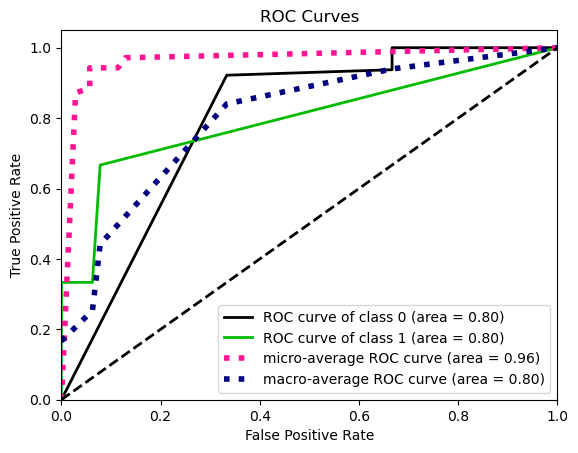

In [28]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

In [29]:
# storing class 1 ROC curve for successive comparisons
y_score = clf.predict_proba(X_test)
fpr0, tpr0, _ = roc_curve(y_test, y_score[:, 1])
roc_auc0 = auc(fpr0, tpr0)

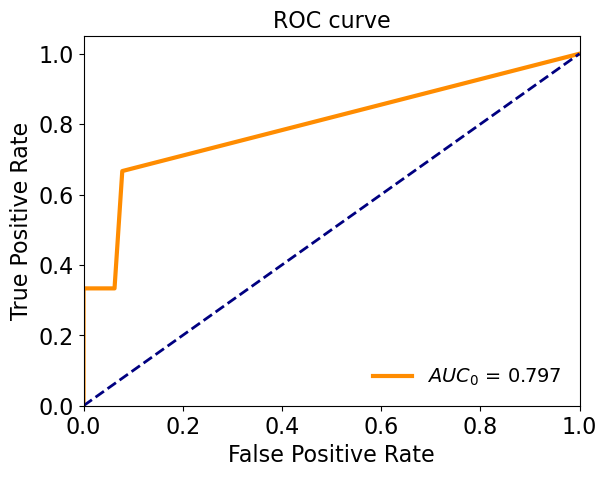

In [30]:
plt.plot(fpr0, tpr0, color='darkorange', lw=3, label='$AUC_0$ = %.3f' % (roc_auc0))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve', fontsize=16)
plt.legend(loc="lower right", fontsize=14, frameon=False)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [31]:
def plot_ROC_comparison(fpr, tpr):
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr0, tpr0, color='darkorange', lw=3, label='$AUC_0$ = %.3f' % (roc_auc0))
    plt.plot(fpr, tpr, color='green', lw=3, label='$AUC_1$ = %.3f' % (roc_auc))
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.title('ROC curve', fontsize=16)
    plt.legend(loc="lower right", fontsize=14, frameon=False)
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.show()

## PCA

In [32]:
from sklearn.decomposition import PCA

In [33]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
    plt.show()

In [34]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
print(X_train.shape, X_pca.shape)

(162, 30) (162, 2)


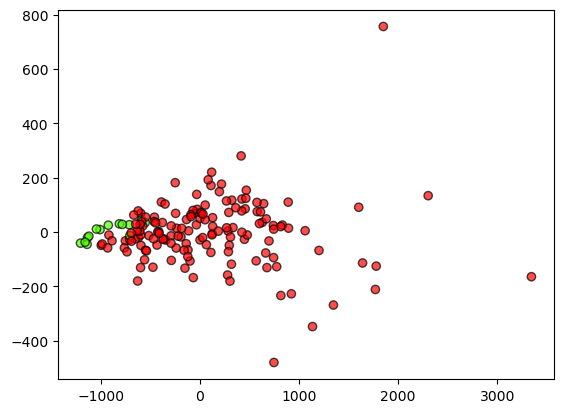

In [35]:
plot_pca(X_pca, y_train)

# Undersampling

In [36]:
# !pip install imblearn

In [37]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

### RandomUnderSampler

In [38]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 14, 1: 14})


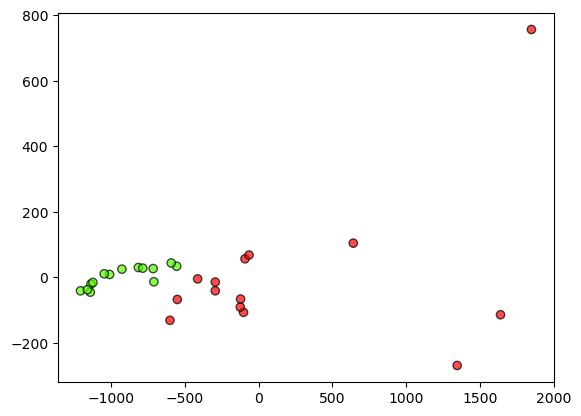

In [39]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8571428571428571
F1-score [0.91525424 0.54545455]
              precision    recall  f1-score   support

           0       1.00      0.84      0.92        64
           1       0.38      1.00      0.55         6

    accuracy                           0.86        70
   macro avg       0.69      0.92      0.73        70
weighted avg       0.95      0.86      0.88        70



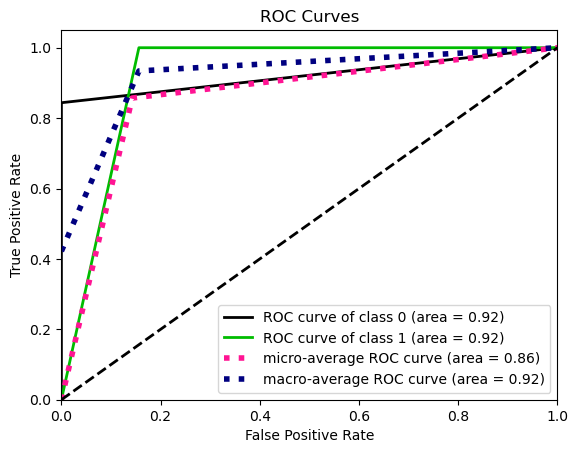

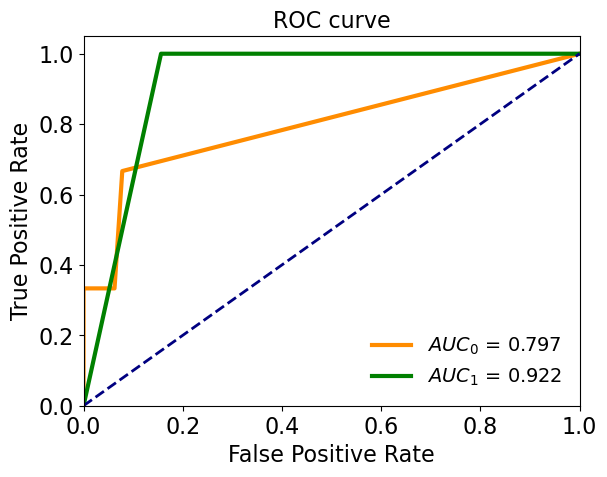

In [40]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

### CondensedNearestNeighbour

In [41]:
import warnings
warnings.simplefilter("ignore")

In [42]:
cnn = CondensedNearestNeighbour(random_state=42, n_jobs=10)
X_res, y_res = cnn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 16, 1: 14})


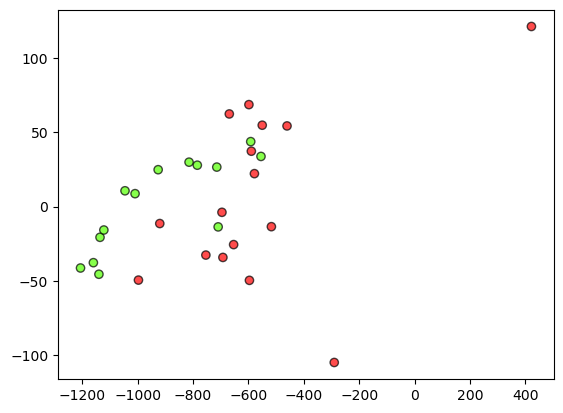

In [43]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.9285714285714286
F1-score [0.96183206 0.44444444]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        64
           1       0.67      0.33      0.44         6

    accuracy                           0.93        70
   macro avg       0.80      0.66      0.70        70
weighted avg       0.92      0.93      0.92        70



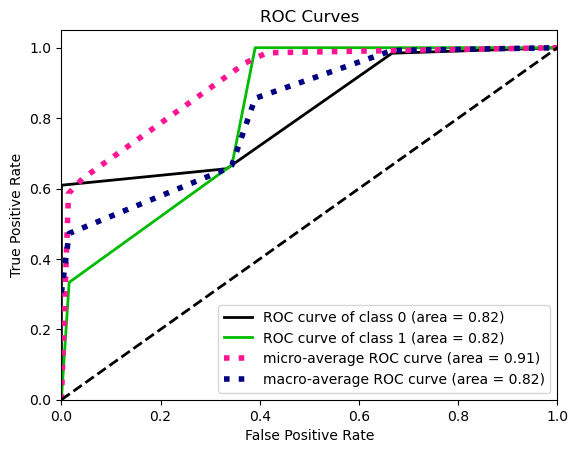

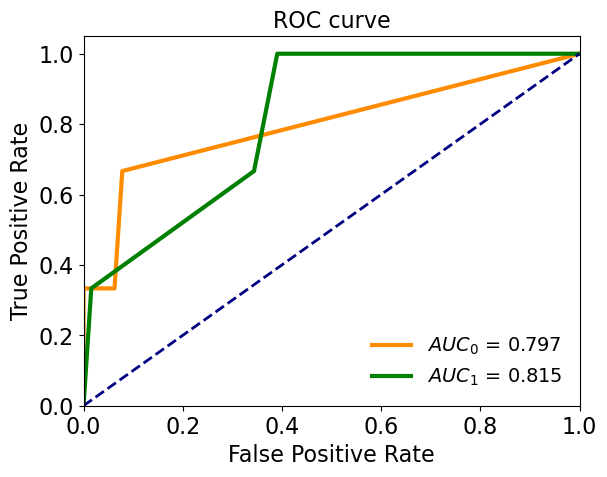

In [44]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

### Tomek Links

In [45]:
tl = TomekLinks()
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 146, 1: 14})


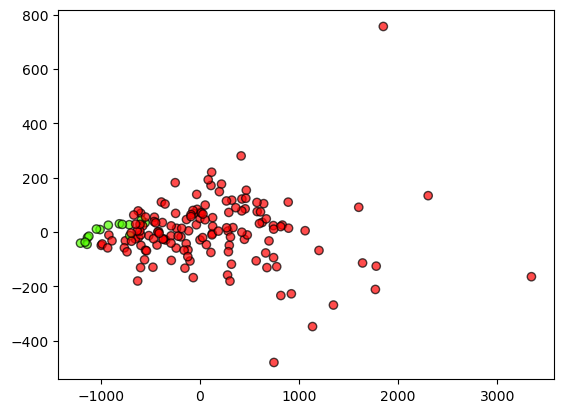

In [46]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.9428571428571428
F1-score [0.96969697 0.5       ]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        64
           1       1.00      0.33      0.50         6

    accuracy                           0.94        70
   macro avg       0.97      0.67      0.73        70
weighted avg       0.95      0.94      0.93        70



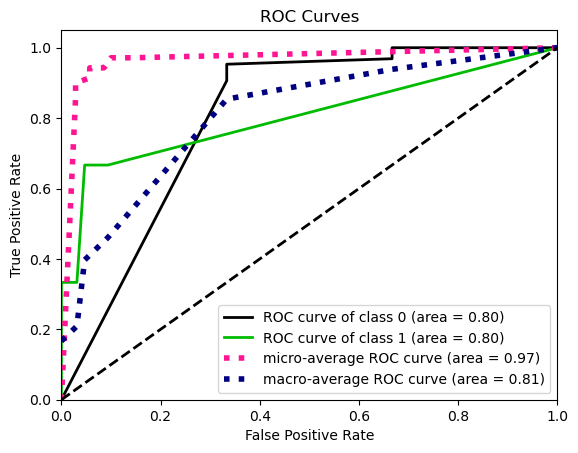

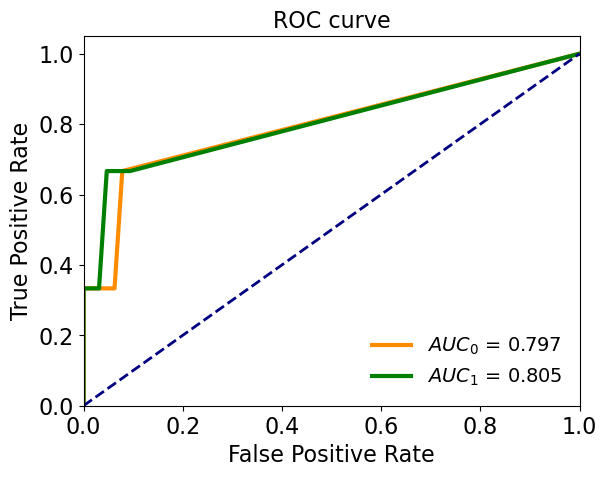

In [47]:
# fit 
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

### Edited Nearest Neighbors

In [48]:
enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 134, 1: 14})


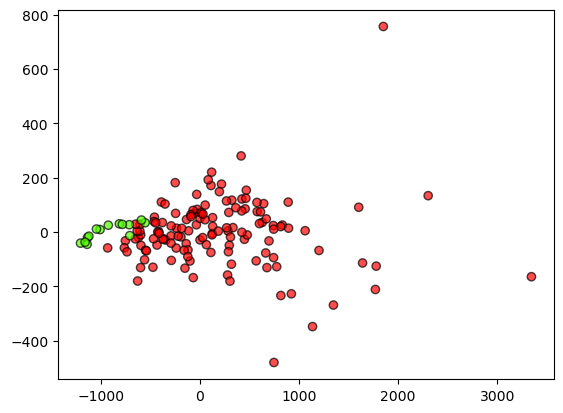

In [49]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.9714285714285714
F1-score [0.98412698 0.85714286]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        64
           1       0.75      1.00      0.86         6

    accuracy                           0.97        70
   macro avg       0.88      0.98      0.92        70
weighted avg       0.98      0.97      0.97        70



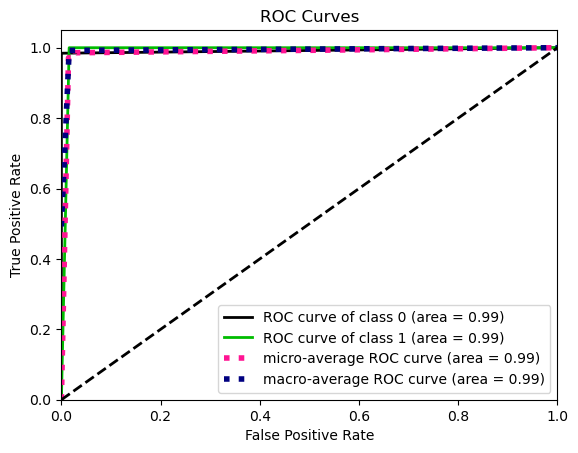

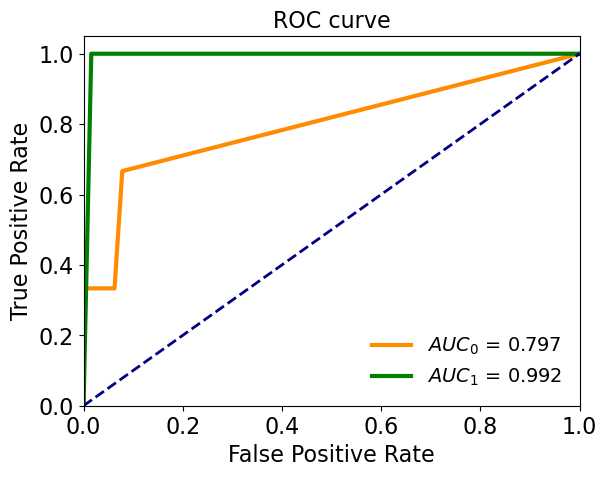

In [50]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

### Cluster Centroids

In [51]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

In [52]:
cc = ClusterCentroids(
    estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42
)
X_res, y_res = cc.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 212, 1: 212})


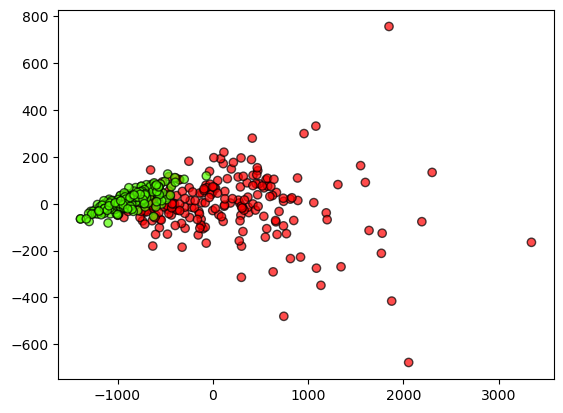

In [53]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.9714285714285714
F1-score [0.98412698 0.85714286]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        64
           1       0.75      1.00      0.86         6

    accuracy                           0.97        70
   macro avg       0.88      0.98      0.92        70
weighted avg       0.98      0.97      0.97        70



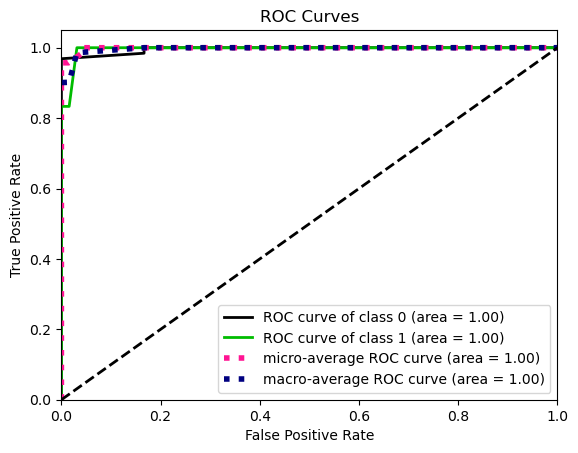

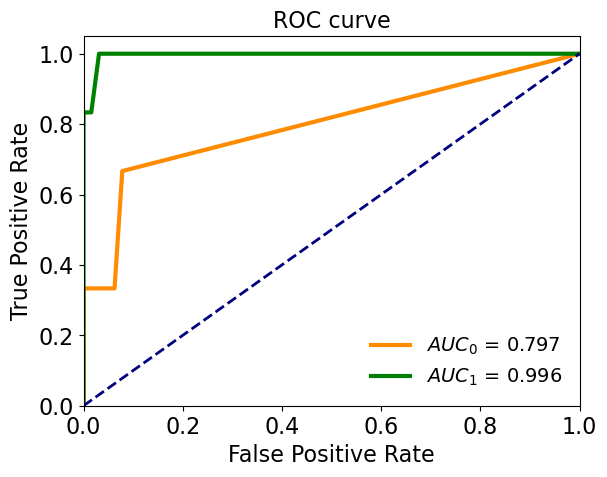

In [54]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

# Oversampling

In [55]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

### RandomOverSampler

In [56]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 148, 1: 148})


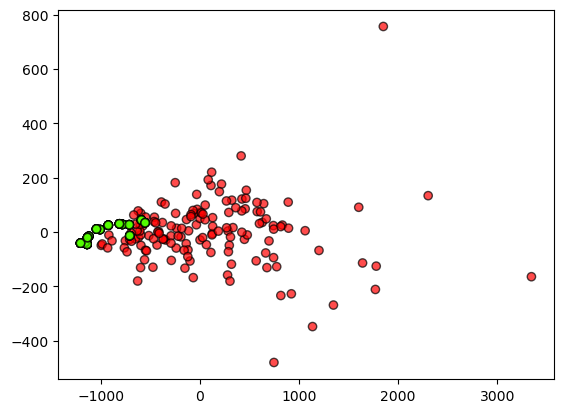

In [57]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.9714285714285714
F1-score [0.98461538 0.8       ]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        64
           1       1.00      0.67      0.80         6

    accuracy                           0.97        70
   macro avg       0.98      0.83      0.89        70
weighted avg       0.97      0.97      0.97        70



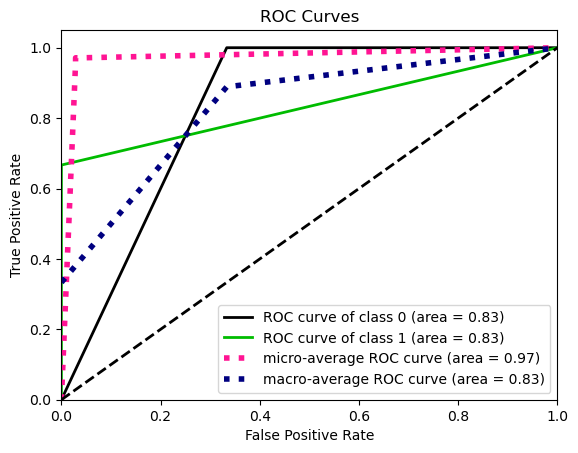

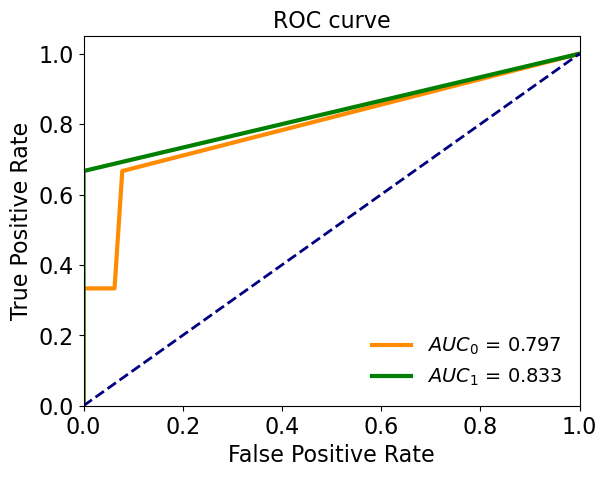

In [58]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict 
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

### SMOTE

In [59]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 148, 1: 148})


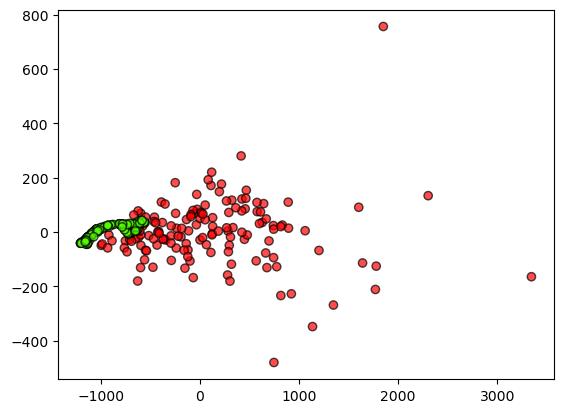

In [60]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.9714285714285714
F1-score [0.98461538 0.8       ]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        64
           1       1.00      0.67      0.80         6

    accuracy                           0.97        70
   macro avg       0.98      0.83      0.89        70
weighted avg       0.97      0.97      0.97        70



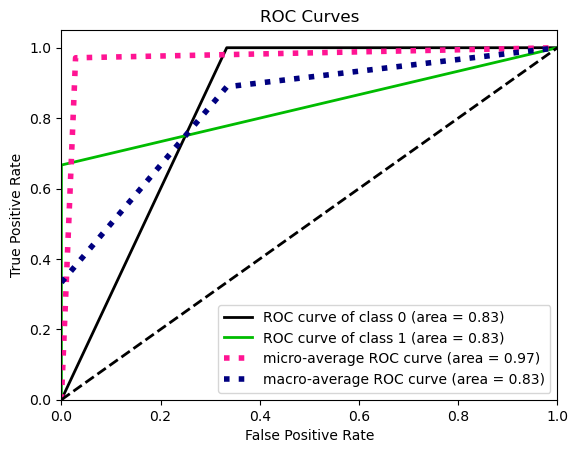

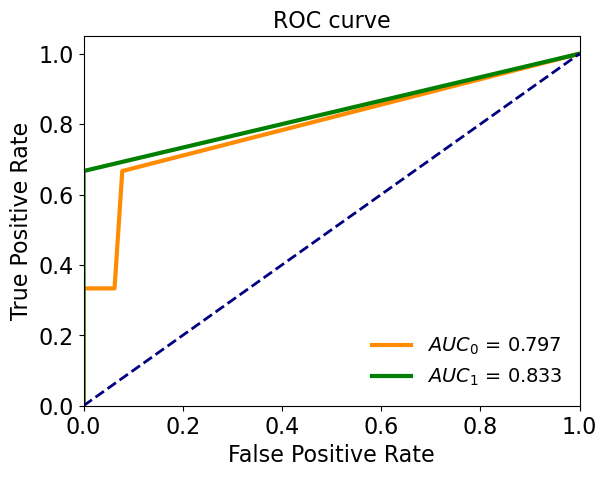

In [61]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

### ADASYN

In [62]:
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 358, 1: 357})


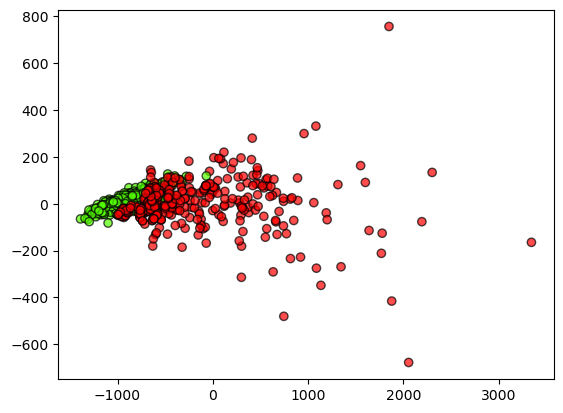

In [63]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.9857142857142858
F1-score [0.99212598 0.92307692]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        64
           1       0.86      1.00      0.92         6

    accuracy                           0.99        70
   macro avg       0.93      0.99      0.96        70
weighted avg       0.99      0.99      0.99        70



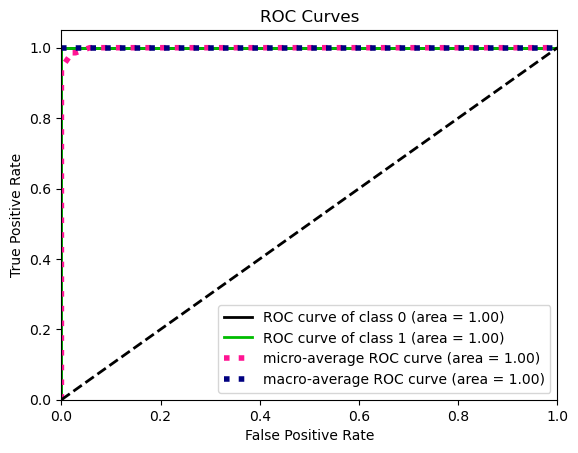

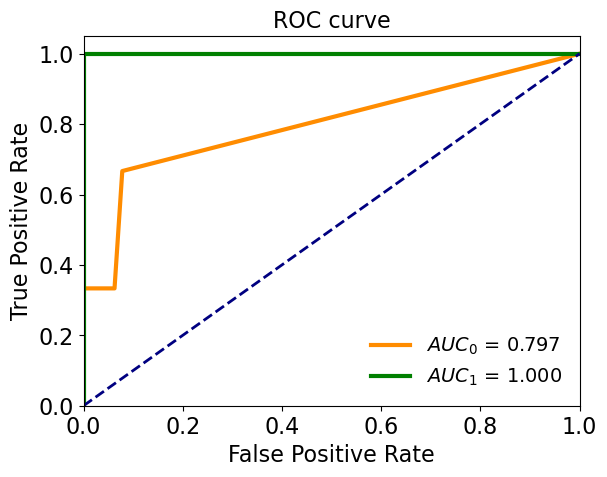

In [64]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

# Balancing at the Algorithm Level

### Class Weight

Accuracy 0.9
F1-score [0.944      0.53333333]
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        64
           1       0.44      0.67      0.53         6

    accuracy                           0.90        70
   macro avg       0.71      0.79      0.74        70
weighted avg       0.92      0.90      0.91        70



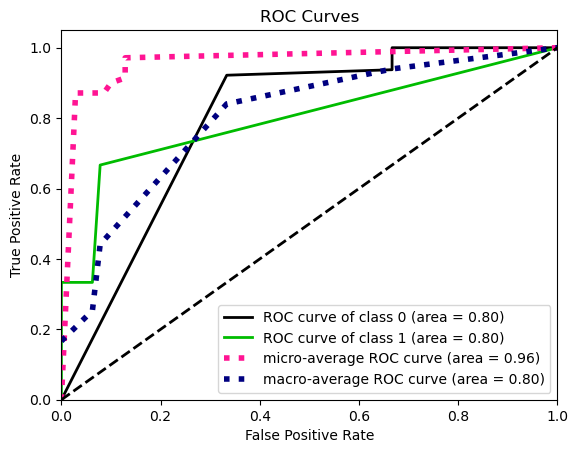

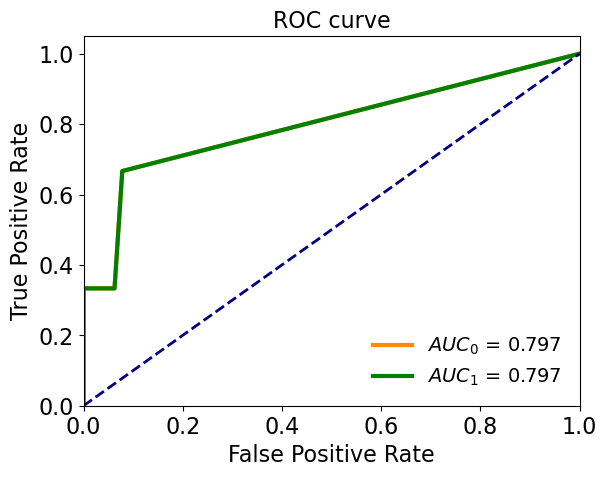

In [65]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, 
                             class_weight={0:1, 1: 5}, random_state=42)
clf.fit(X_train, y_train)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

### Decision Threshold

Accuracy 0.9428571428571428
F1-score [0.96969697 0.5       ]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        64
           1       1.00      0.33      0.50         6

    accuracy                           0.94        70
   macro avg       0.97      0.67      0.73        70
weighted avg       0.95      0.94      0.93        70



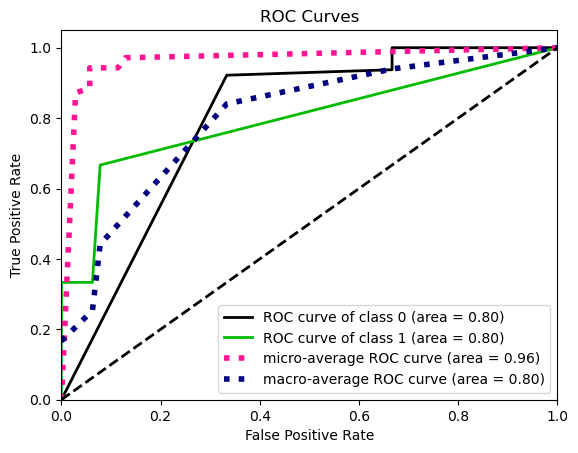

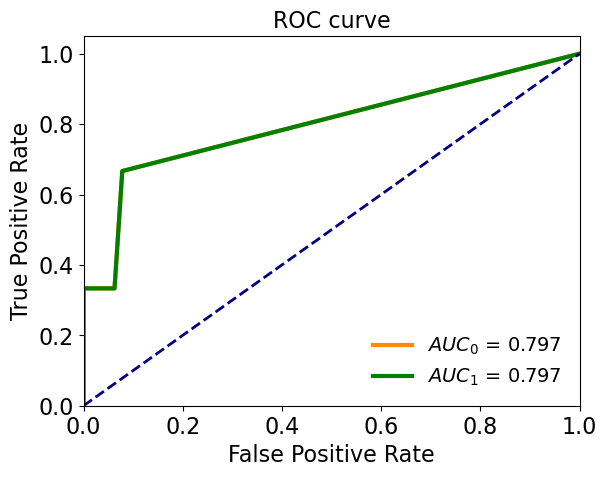

In [66]:
def adjusted_predict(X, thr=0.5):
    y_score = clf.predict_proba(X_test)[:, 1]
    return np.array([1 if y > thr else 0 for y in y_score])

# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

# predict
y_pred = adjusted_predict(X_test, thr=0.9)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

# Meta-Cost Sensitive Classifier

In [67]:
# Credits to Simone Di Luna
import sys
import joblib
import six
import sklearn.ensemble._base
sys.modules['sklearn.externals.joblib'] = joblib
sys.modules['sklearn.externals.six'] = six
sys.modules['sklearn.externals.six.moves'] = six.moves
sys.modules['sklearn.ensemble.base'] = sklearn.ensemble._base

In [70]:
!pip install costcla

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------------- -------------------------- 1.3/4.0 MB 7.4 MB/s eta 0:00:01
   ---------------------------------- ----- 3.4/4.0 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 8.2 MB/s eta 0:00:00
  Created wheel for pyea: filename=pyea-0.2-py3-none-any.whl size=6060 sha256=d70b73e043a33e1fab2d291e04d7eb1c015aa84f2b04d580c682ff8c0fb405f1
  Stored in directory: c:\users\paula\appdata\local\pip\cache\wheels\c9\ec\02\9d7903961a36129e95e0f60240bb440f908e579331b2ced296
Successfully built pyea

   -------------------- ------------------- 1/2 [costcla]
   ---------------------------------------- 2/2 [costcla]



  DEPRECATION: Building 'pyea' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pyea'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [ ]:
import sys, sklearn
print(sys.version)        # probably 3.11+ or 3.12
print(sklearn.__version__) # probably 1.0+

In [75]:
# Run this BEFORE any costcla import — patches the broken files in memory

import inspect
if not hasattr(inspect, 'getargspec'):
    inspect.getargspec = inspect.getfullargspec  # ← restore removed function

import joblib
import sklearn.externals
if not hasattr(sklearn.externals, 'joblib'):
    sklearn.externals.joblib = joblib            # ← restore removed module

# NOW import costcla safely
from costcla.models import CostSensitiveDecisionTreeClassifier
from costcla.metrics import savings_score

In [76]:
from costcla.models import CostSensitiveDecisionTreeClassifier
from costcla.metrics import savings_score

cost_mat : array-like of shape = [n_samples, 4]

Cost matrix of the classification problem Where the columns represents the costs of: false positives, false negatives, true positives and true negatives, for each example.

In [77]:
cost = [1, 10, 0, 0]
cost_mat = np.array([cost] * len(X_train))
cost_mat.shape

(162, 4)

In [78]:
cost_mat

array([[ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],


In [79]:
np.float = float # workaround necessary for np versions >= 1.20.0
clf = CostSensitiveDecisionTreeClassifier()
clf.fit(X_train, y_train, cost_mat)

CostSensitiveDecisionTreeClassifier()

Accuracy 0.9285714285714286
F1-score [0.96124031 0.54545455]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        64
           1       0.60      0.50      0.55         6

    accuracy                           0.93        70
   macro avg       0.78      0.73      0.75        70
weighted avg       0.92      0.93      0.93        70



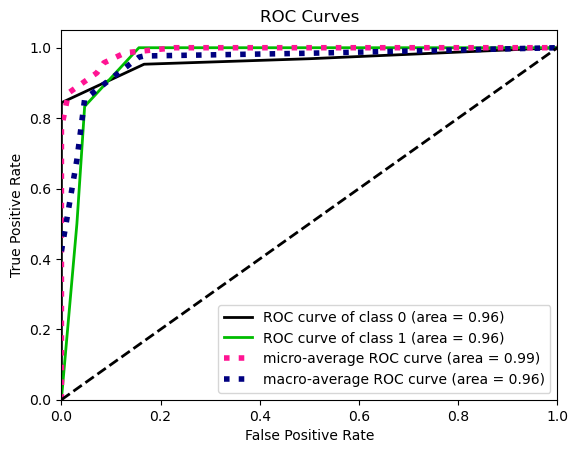

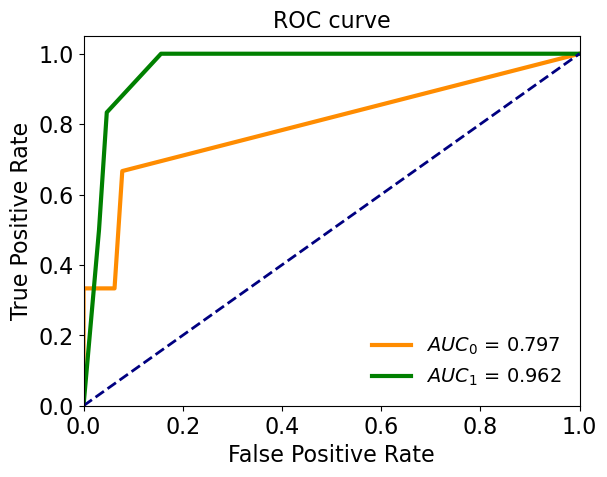

In [80]:
# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

In [81]:
cost_mat_test = np.array([cost] * len(X_test))
print(savings_score(y_test, y_pred, cost_mat_test))
print(savings_score(y_test, y_pred0, cost_mat_test))

0.4666666666666667
0.33333333333333337


# Corrected Decision Tree

In [82]:
from sklearn.tree._tree import TREE_LEAF

In [83]:
def is_leaf(inner_tree, index):
    # Check whether node is leaf node
    return (inner_tree.children_left[index] == TREE_LEAF and
            inner_tree.children_right[index] == TREE_LEAF)


def prune_index(inner_tree, decisions, index=0):
    # Start pruning from the bottom - if we start from the top, we might miss
    # nodes that become leaves during pruning.
    # Do not use this directly - use prune_duplicate_leaves instead.
    if not is_leaf(inner_tree, inner_tree.children_left[index]):
        prune_index(inner_tree, decisions, inner_tree.children_left[index])
    if not is_leaf(inner_tree, inner_tree.children_right[index]):
        prune_index(inner_tree, decisions, inner_tree.children_right[index])

    # Prune children if both children are leaves now and make the same decision:
    if (is_leaf(inner_tree, inner_tree.children_left[index]) and
        is_leaf(inner_tree, inner_tree.children_right[index]) and
        (decisions[index] == decisions[inner_tree.children_left[index]]) and
        (decisions[index] == decisions[inner_tree.children_right[index]])):
        # turn node into a leaf by "unlinking" its children
        inner_tree.children_left[index] = TREE_LEAF
        inner_tree.children_right[index] = TREE_LEAF
        # print("Pruned {}".format(index))


def prune_duplicate_leaves(dt):
    # Remove leaves if both
    decisions = dt.tree_.value.argmax(axis=2).flatten().tolist()  # Decision for each node
    prune_index(dt.tree_, decisions)

In [84]:
import numpy as np
from sklearn.datasets import load_iris

frame = load_iris(as_frame=True)
df = frame['data']
X = df.values
y = np.array(frame['target'])

In [85]:
from sklearn.tree import DecisionTreeClassifier

In [86]:
from sklearn import tree
import matplotlib.pyplot as plt

In [87]:
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=3)

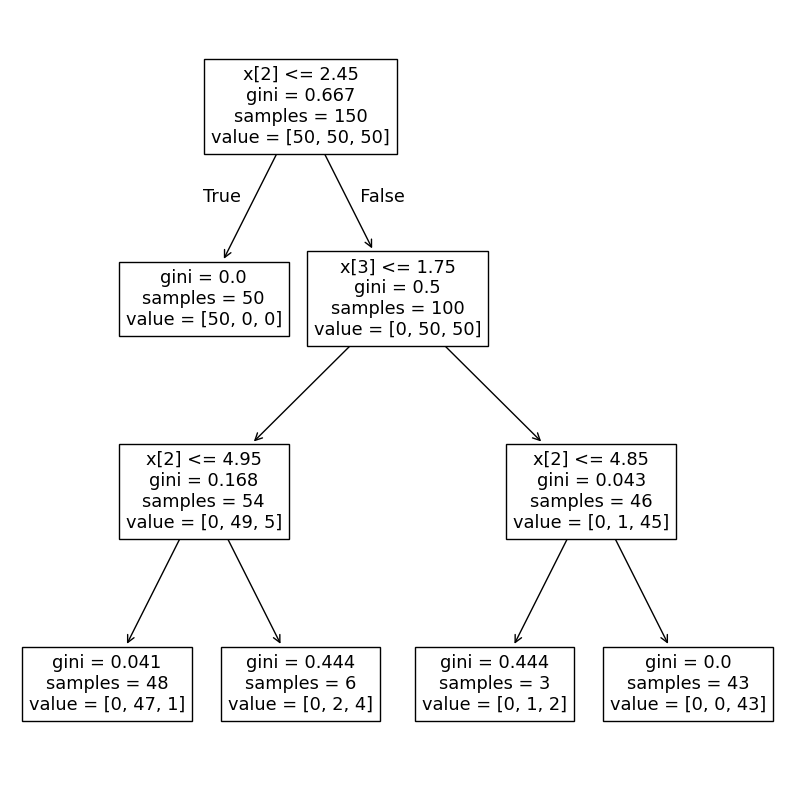

In [88]:
plt.figure(figsize=(10,10))
tree.plot_tree(clf)
plt.show()

In [89]:
prune_duplicate_leaves(clf)

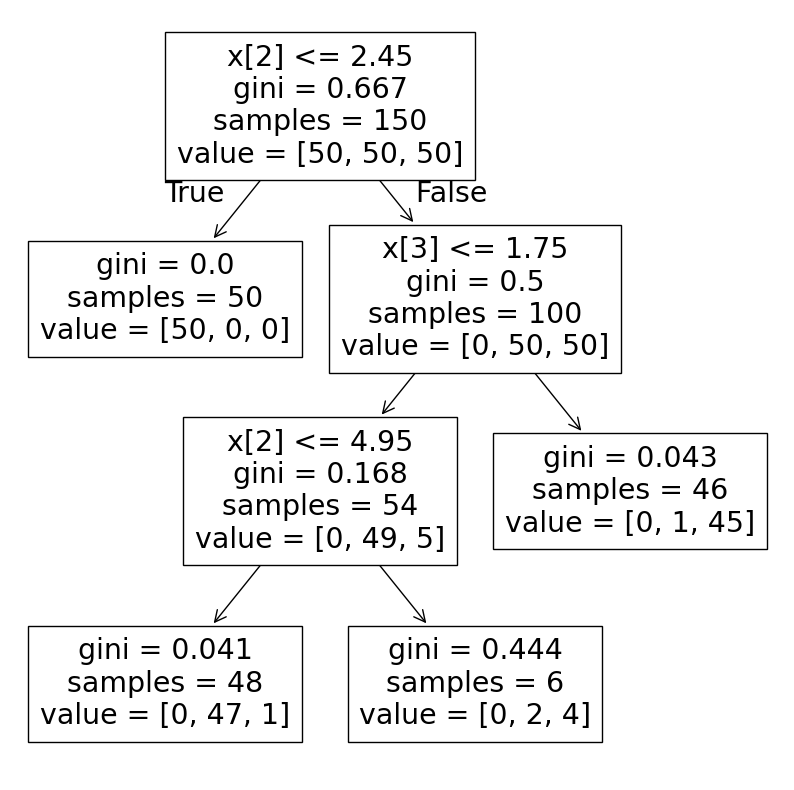

In [90]:
plt.figure(figsize=(10,10))
tree.plot_tree(clf)
plt.show()